In [16]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

#PROJECT_ROOT = Path.cwd()
#if not (PROJECT_ROOT / "scripts").is_dir():
#    raise RuntimeError("Start Jupyter from the Gresse repository root.")
#sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

from plot_geo_churn import (
    latest_result_dir,
    load_experiment_data,
    state_size_dataframe,
    system_latency_dataframe,
    topology_change_dataframe,
    request_latency_dataframe,
    ExperimentData,
)

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

def paper_figure(width=7.16, height=2.0):
    """Create a two-column, paper-ready Matplotlib figure in inches."""
    return plt.figure(figsize=(width, height), constrained_layout=True)


In [17]:
# Replace this with a specific completed run when preparing the paper.
# RESULT_DIR = latest_result_dir("../results/geo_churn/")
RESULT_DIR = "../results/geo_churn/geo-churn-20260903T091322Z-c5c529df"

data: ExperimentData = load_experiment_data(RESULT_DIR)
print(
    data.replicas.loc[data.replicas.event.eq("client_mutation"), "experiment_time_s"]
    .agg(["count", "min", "max"])
)
system_latencies = system_latency_dataframe(data)
#topology_changes = topology_change_dataframe(data)
request_latencies = request_latency_dataframe(data.events)
state_sizes = state_size_dataframe(data)

print(f"Loaded {RESULT_DIR}")
display(system_latencies.groupby("latency_type").size().rename("samples"))


count    333344.000000
min         119.593123
max        7303.632432
Name: experiment_time_s, dtype: float64
Loaded ../results/geo_churn/geo-churn-20260903T091322Z-c5c529df


latency_type
Cancelled GC attempt          340
GC round                      115
P2P pull to delta merge    131560
Replica initialization        203
Replica recovery              177
Name: samples, dtype: int64

In [18]:
def delta_merge_dataframe(data: ExperimentData) -> pd.DataFrame:
    merges = data.replicas.loc[
        data.replicas["event"].eq("peer_replication_merge_delta")
        & data.replicas["phase"].eq("completed")
    ].copy()

    for column in ("received_us", "start_us", "end_us"):
        merges[column] = pd.to_numeric(merges[column], errors="coerce")

    merges["delta_len"] = pd.to_numeric(
        merges["detail"].astype("string")
        .str.extract(r"delta_len=(\d+)", expand=False),
        errors="coerce",
    )

    # Includes commit-gate waiting, journal serialization/fsync, and CRDT apply.
    merges["total_latency_ms"] = (
        merges["end_us"] - merges["received_us"]
    ) / 1_000

    # start_us is recorded after persist_delta_before_apply().
    merges["gate_and_journal_ms"] = (
        merges["start_us"] - merges["received_us"]
    ) / 1_000

    merges["apply_ms"] = (
        merges["end_us"] - merges["start_us"]
    ) / 1_000

    return merges.loc[
        merges["total_latency_ms"].ge(0)
    ].sort_values("experiment_time_s")


delta_merges = delta_merge_dataframe(data)

{'color': 'black', 'marker': '.'}
Cancelled GC attempt
{'color': 'black', 'marker': 'o'}
GC round
{'color': 'red', 'marker': 'd'}
Replica initialization
{'color': 'red', 'marker': 's'}
Replica recovery


/var/folders/tz/fvx5t98176g0bbx35x9zpjdr0000gn/T/ipykernel_89822/3544820912.py:127: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


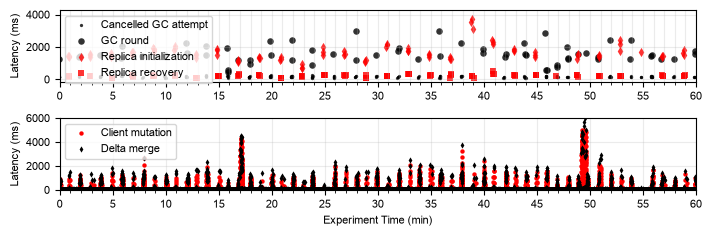

In [37]:
fig = paper_figure(7.16, 2.4)
XLIM_LOW = 3400
XLIM_HIGH = 7000

SYSTEM_LATENCY_STYLES = {
    "Cancelled GC attempt": {"color": "black", "marker": "."},
    "GC round": {"color": "black", "marker": "o"},
    "Replica initialization": {"color": "red", "marker": "d"},
    "Replica recovery": {"color": "red", "marker": "s"},
}

def scatter_system_latencies(
    axis,
    dataframe: pd.DataFrame
) -> plt.Axes:
    """Plot system-operation latencies and topology-change initiation markers."""
    
    colors = plt.get_cmap("tab10")
    for index, (kind, group) in enumerate(dataframe.groupby("latency_type", sort=True)):
        if kind == "P2P pull to delta merge":
            continue;
        style = SYSTEM_LATENCY_STYLES[kind]
        print(style)
        axis.scatter(group["experiment_time_s"], group["latency_ms"], label=kind,
                     color=style["color"], marker=style["marker"],
                     alpha=0.8, s=22, linewidths=0, rasterized=True)
        print(kind)
    change_colors = {"crash": "#d62728", "graceful_stop": "#9467bd", "spawn": "#2ca02c"}
    #for _, change in topology_changes.iterrows():
    #    action = change["action"]
    #    axis.axvline(change["experiment_time_s"], color=change_colors.get(action, "#555555"),
    #                 linestyle="--", linewidth=1.1, alpha=0.75, label=f"topology: {action}")
    handles, labels = axis.get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    # axis.set_title("System-operations and client request latencies during geo-distributed churn")
    # axis.set_xlabel("Experiment time (s)")
    axis.set_ylabel("Latency (ms)")
    axis.set_xlim(XLIM_LOW, XLIM_HIGH)
    # axis.set_ylim(1,5000)
    # axis.set_yscale("log")
    axis.grid(True, which="both", alpha=0.25)
    if unique:
        axis.legend(unique.values(), unique.keys(), loc="upper left")
    # axis.set_xlabel("Experiment time (s)")
    axis.set_ylabel("Latency (ms)")
    return axis

axis = fig.add_subplot(2, 1, 1)
scatter_system_latencies(axis, system_latencies)

REQUEST_LATENCY_STYLES = {
    "replica: client mutation": {
        "label": "Client mutation", "color": "red",
        "marker": "o", "size": 10, "alpha": 1.0, "zorder": 2,
    },
    "Delta merge": {
        "label": "Delta merge", "color": "black",
        "marker": "d", "size": 10, "alpha": 1.0, "zorder": 3,
    },
}

def scatter_latency(
    axis,
    dataframe: pd.DataFrame,
    *,
    title: str = "Request latency during geo-distributed churn",
) -> plt.Axes:
    """Scatter request latency over experiment time, grouped into a legend."""
    if dataframe.empty:
        axis.set_title(title)
        axis.set_xlabel("Experiment time (s)")
        axis.set_ylabel("Latency (ms)")
        return axis

    for kind, group in dataframe.groupby("latency_type", sort=False):
        style = REQUEST_LATENCY_STYLES.get(kind)
        if style is None:
            continue
        axis.scatter(
            group["experiment_time_s"], group["latency_ms"],
            label=style["label"], color=style["color"],
            marker=style["marker"], alpha=style["alpha"],
            s=style["size"], linewidths=0, zorder=style["zorder"],
            rasterized=True,
        )
    axis.set_xlabel("Experiment time (s)")
    axis.set_ylabel("Latency (ms)")
    axis.set_xlim(XLIM_LOW, XLIM_HIGH)
    axis.grid(True, alpha=0.25)
    axis.legend(loc="upper left")
    axis.set_ylim(0,6000)
    # axis.legend(title="Trace", loc="best")
    return axis

delta_merge_latencies = delta_merges[["experiment_time_s", "total_latency_ms"]].rename(
    columns={"total_latency_ms": "latency_ms"}
)
delta_merge_latencies["latency_type"] = "Delta merge"
request_latencies_with_delta_merges = pd.concat(
    [request_latencies, delta_merge_latencies], ignore_index=True
)

request_axis = fig.add_subplot(2, 1, 2)
scatter_latency(request_axis, request_latencies_with_delta_merges)

# state_axis = request_axis.twinx()
# state_axis.plot(
#     state_sizes["experiment_time_s"],
#     state_sizes["state_mib"],
#     color="tab:blue", marker="o", markersize=2.5, linewidth=1.0,
#     alpha=0.85, label="Persistent state size",
# )
# state_axis.set_ylabel("State size (MiB)", color="tab:blue")
# state_axis.tick_params(axis="y", labelcolor="tab:blue")
# state_axis.legend(loc="upper left")

from matplotlib.ticker import FixedLocator, FuncFormatter

major_ticks = list(range(XLIM_LOW, XLIM_HIGH + 1, 5 * 60))
minor_ticks = list(range(XLIM_LOW, XLIM_HIGH + 1, 60))
minute_formatter = FuncFormatter(lambda value, _: f"{(value - XLIM_LOW) / 60:.0f}")
for plot_axis in (fig.axes[0], request_axis):
    plot_axis.xaxis.set_major_locator(FixedLocator(major_ticks))
    plot_axis.xaxis.set_minor_locator(FixedLocator(minor_ticks))
    plot_axis.xaxis.set_major_formatter(minute_formatter)
request_axis.set_xlabel("Experiment Time (min)")
fig.tight_layout()
fig.savefig("../results/plots/geo_churn/geo_distributed_churn.pdf", bbox_inches="tight")


In [36]:
client_latencies = request_latencies.loc[
    request_latencies["latency_type"].eq("replica: client mutation")
    & request_latencies["experiment_time_s"].between(XLIM_LOW, XLIM_HIGH),
    "latency_ms",
]

client_latencies.quantile([0.90, 0.95, 0.99]).rename(
    index={0.90: "P90", 0.95: "P95", 0.99: "P99"}
)

P90      2.7340
P95      3.8730
P99    123.7614
Name: latency_ms, dtype: float64